1. Data Exploration and Preprocessing

In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [4]:
df = pd.read_csv("C:/Users/HP/Downloads/AI Engineer Assignment/AI Engineer Assignment/sensor.csv")

# Display the first few rows of the DataFrame
print(df.head())

   Unnamed: 0            timestamp  sensor_00  sensor_01  sensor_02  \
0           0  2018-04-01 00:00:00   2.465394   47.09201    53.2118   
1           1  2018-04-01 00:01:00   2.465394   47.09201    53.2118   
2           2  2018-04-01 00:02:00   2.444734   47.35243    53.2118   
3           3  2018-04-01 00:03:00   2.460474   47.09201    53.1684   
4           4  2018-04-01 00:04:00   2.445718   47.13541    53.2118   

   sensor_03  sensor_04  sensor_05  sensor_06  sensor_07  ...  sensor_43  \
0  46.310760   634.3750   76.45975   13.41146   16.13136  ...   41.92708   
1  46.310760   634.3750   76.45975   13.41146   16.13136  ...   41.92708   
2  46.397570   638.8889   73.54598   13.32465   16.03733  ...   41.66666   
3  46.397568   628.1250   76.98898   13.31742   16.24711  ...   40.88541   
4  46.397568   636.4583   76.58897   13.35359   16.21094  ...   41.40625   

   sensor_44  sensor_45  sensor_46  sensor_47  sensor_48  sensor_49  \
0  39.641200   65.68287   50.92593  38.194440

In [6]:
# Explore the DataFrame's information
print(df.info())

# Check for missing values
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15 

In [8]:
def plot_class_distribution(df, column_name):
    """
    Plots the class distribution of a categorical column in a DataFrame.

    Parameters:
    - df (pd.DataFrame): The DataFrame containing the data.
    - column_name (str): The name of the categorical column to visualize.

    Returns:
    - None (displays the plot)
    """
    # Calculate class distribution
    class_counts = df[column_name].value_counts()

    # Create bar plot
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column_name, data=df, order=class_counts.index)

    # Add count annotations to bars
    for i, count in enumerate(class_counts):
        plt.text(i, count + 1, str(count), ha='center', va='bottom')

    plt.title(f'Class Distribution of {column_name}')
    plt.xlabel(column_name)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

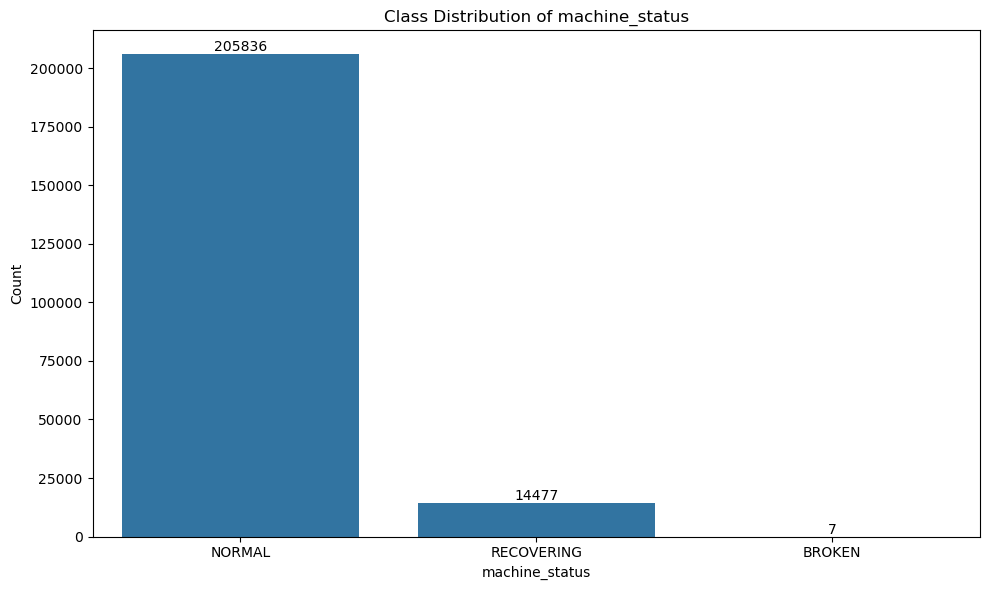

In [10]:
plot_class_distribution(df, 'machine_status')

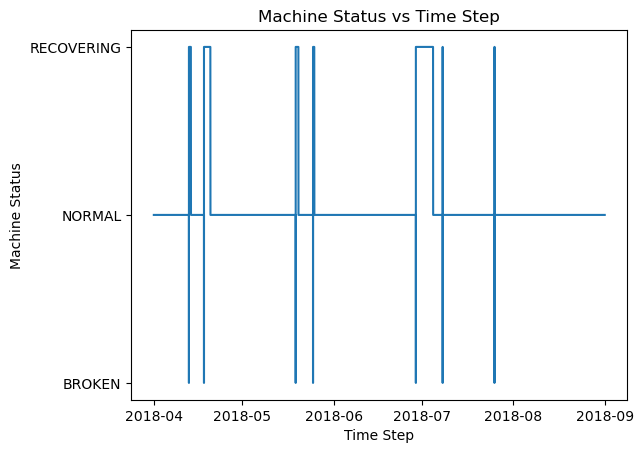

In [12]:
# Convert 'timestamp' to datetime objects if it's not already
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Create a LabelEncoder object
le = LabelEncoder()

y = le.fit_transform(df['machine_status']) # fitting on labels
plt.plot(df['timestamp'], y)
plt.xlabel('Time Step')
plt.ylabel('Machine Status')
plt.title('Machine Status vs Time Step')

encode_labels = list(le.transform(list(le.classes_))) # encoded labels
labels = list(le.classes_) # labels
plt.yticks(encode_labels, labels)
plt.show()


Class distribution after re-labeling the data



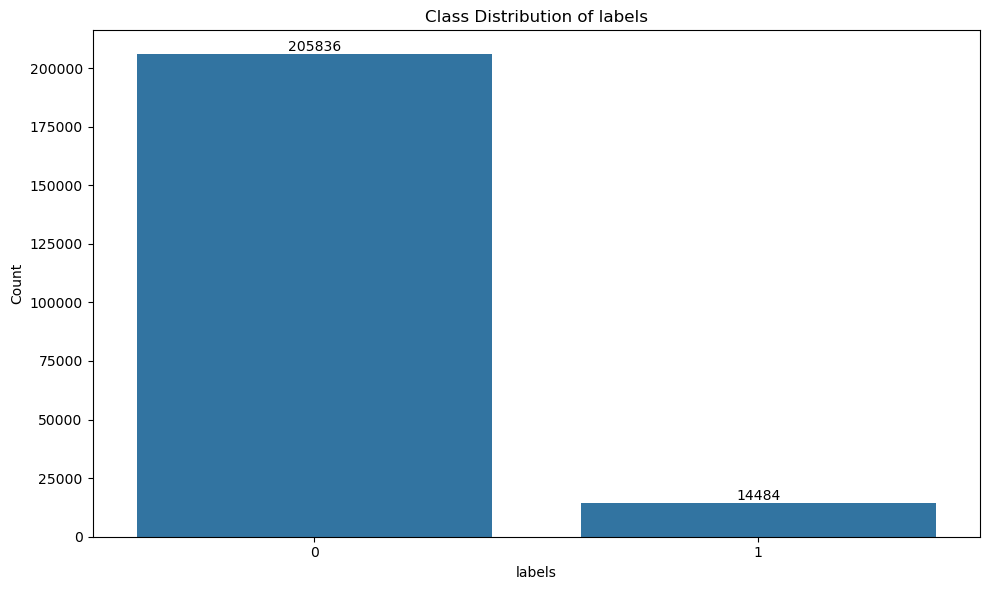


----------------------------------------------------------------------
Machine status after re-labeling the data



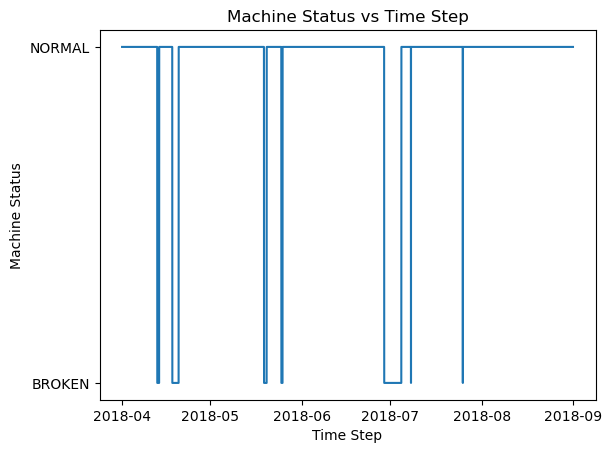

In [14]:
df['labels'] = df['machine_status'].map(lambda label: 0
                                                if label == 'NORMAL' else 1)

print("Class distribution after re-labeling the data")
print()
plot_class_distribution(df, 'labels')
print()
# print('-*'*40)
print('-'*70)

# changing machine status recovery to broken
df['new_machine_status'] = df['machine_status'].map(lambda
                        label:  'BROKEN' if label != 'NORMAL' else 'NORMAL')

print("Machine status after re-labeling the data")
print()

# reversing labels for better visualization
y = list(df['labels'].map(lambda label:  1 if label == 0 else 0))

plt.plot(df['timestamp'], y)
plt.xlabel('Time Step')
plt.ylabel('Machine Status')
plt.title('Machine Status vs Time Step')

encode_labels = [0, 1] # encoded labels
labels = ['BROKEN', 'NORMAL'] # labels
plt.yticks(encode_labels, labels)
plt.show()

Percentage Missing Values 



C:\Users\HP\AppData\Local\Temp\ipykernel_13788\2665459819.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(x=list(percent_null.values()),


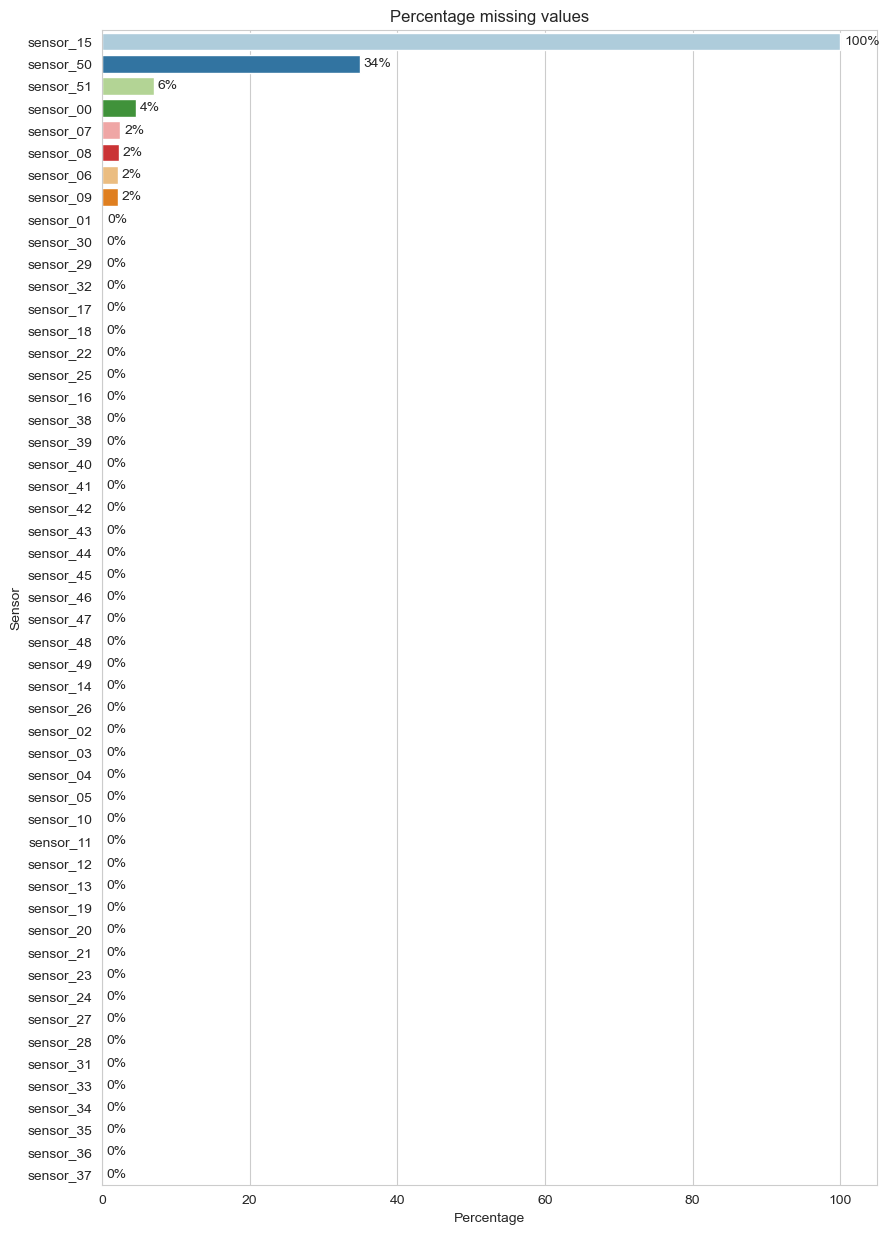

In [16]:
print("Percentage Missing Values ")
print()

# percentage null values
null_count = df.isna().sum()/df.shape[0] * 100
null_count = null_count[2:-3] # considering only sensor columns

percent_null = {}

# creating dictionary of column and percentage null value
for i, j in zip(null_count.index, null_count.values):
    percent_null[i] = j

# sorting the dictionary
percent_null = {k:v for k, v in sorted(percent_null.items(),
                                       key=lambda item: item[1], reverse=True)}

sns.set_style(style="whitegrid")
plt.figure(figsize=(10,15))

plot = sns.barplot(x=list(percent_null.values()),
                   y=list(percent_null.keys()), palette='Paired')

for p in plot.patches:
    _x = p.get_x() + p.get_width() + 0.5
    _y = p.get_y() + p.get_height() - 0.25
    value = f'{int(p.get_width())}%'
    plot.text(_x, _y, value, ha="left")

plot.set_title("Percentage missing values")
plot.set_ylabel("Sensor")
plot.set_xlabel("Percentage")
plt.show()

In [18]:
# Drop specified columns
df = df.drop(['machine_status', 'machine_status_encoded', 'new_machine_status', 'sensor_15', 'Unnamed: 0'], axis=1, errors='ignore')

In [20]:
# filling missing values with -1
for sensor in list(df.columns)[1:-1]:
    df[sensor].fillna(-1, inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_13788\4188641053.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[sensor].fillna(-1, inplace=True)


In [22]:
def shift_labels(sensor_list, df):
    """
    Function to shift labels by 10 min
    """
    new_features = {}

    for sensor in sensor_list:
        new_features[sensor] = df[sensor]

    labels = [None] * df.shape[0]

    for i in range(0, df.shape[0]-10):
        labels[i] = df['labels'][i+10]

    new_features['labels'] = labels
    new_df = pd.DataFrame(new_features)
    # dropping last rows with null value
    new_df.drop(new_df.tail(10).index,inplace=True)
    return new_df

In [24]:
data_10min_shift = shift_labels(df.columns[1:-1], df)
data_10min_shift.head()

,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,sensor_08,sensor_09,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,labels
0,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,0.0
1,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,15.56713,15.05353,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,0.0
2,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,15.61777,15.01013,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,0.0
3,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,15.69734,15.08247,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,0.0
4,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,15.69734,15.08247,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,0.0


In [25]:
def plot_all_sensor_distributions(df):
    """
    Plots the distribution of all sensors (sensor_00 to sensor_51) except sensor_15,
    for Normal and Broken states using subplots.
    """
    # Create list of sensor names, excluding sensor_15
    sensors = [f'sensor_{i:02d}' for i in range(52) if i != 15]
    n_cols = 4
    n_rows = (len(sensors) + n_cols - 1) // n_cols  # ceil division for rows

    plt.figure(figsize=(20, n_rows * 3))

    for idx, sensor in enumerate(sensors):
        plt.subplot(n_rows, n_cols, idx + 1)

        normal = df[df['labels'] == 0][sensor].dropna()
        broken = df[df['labels'] == 1][sensor].dropna()

        sns.kdeplot(normal, label='Normal', linestyle='-', linewidth=1)
        sns.kdeplot(broken, label='Broken', linestyle='--', linewidth=1)

        plt.title(sensor)
        plt.xlabel('Value')
        plt.ylabel('Density')

        if idx == 0:
            plt.legend()

    plt.tight_layout()
    plt.suptitle('Sensor Distributions (Normal vs Broken)', fontsize=16, y=1.02)
    plt.show()

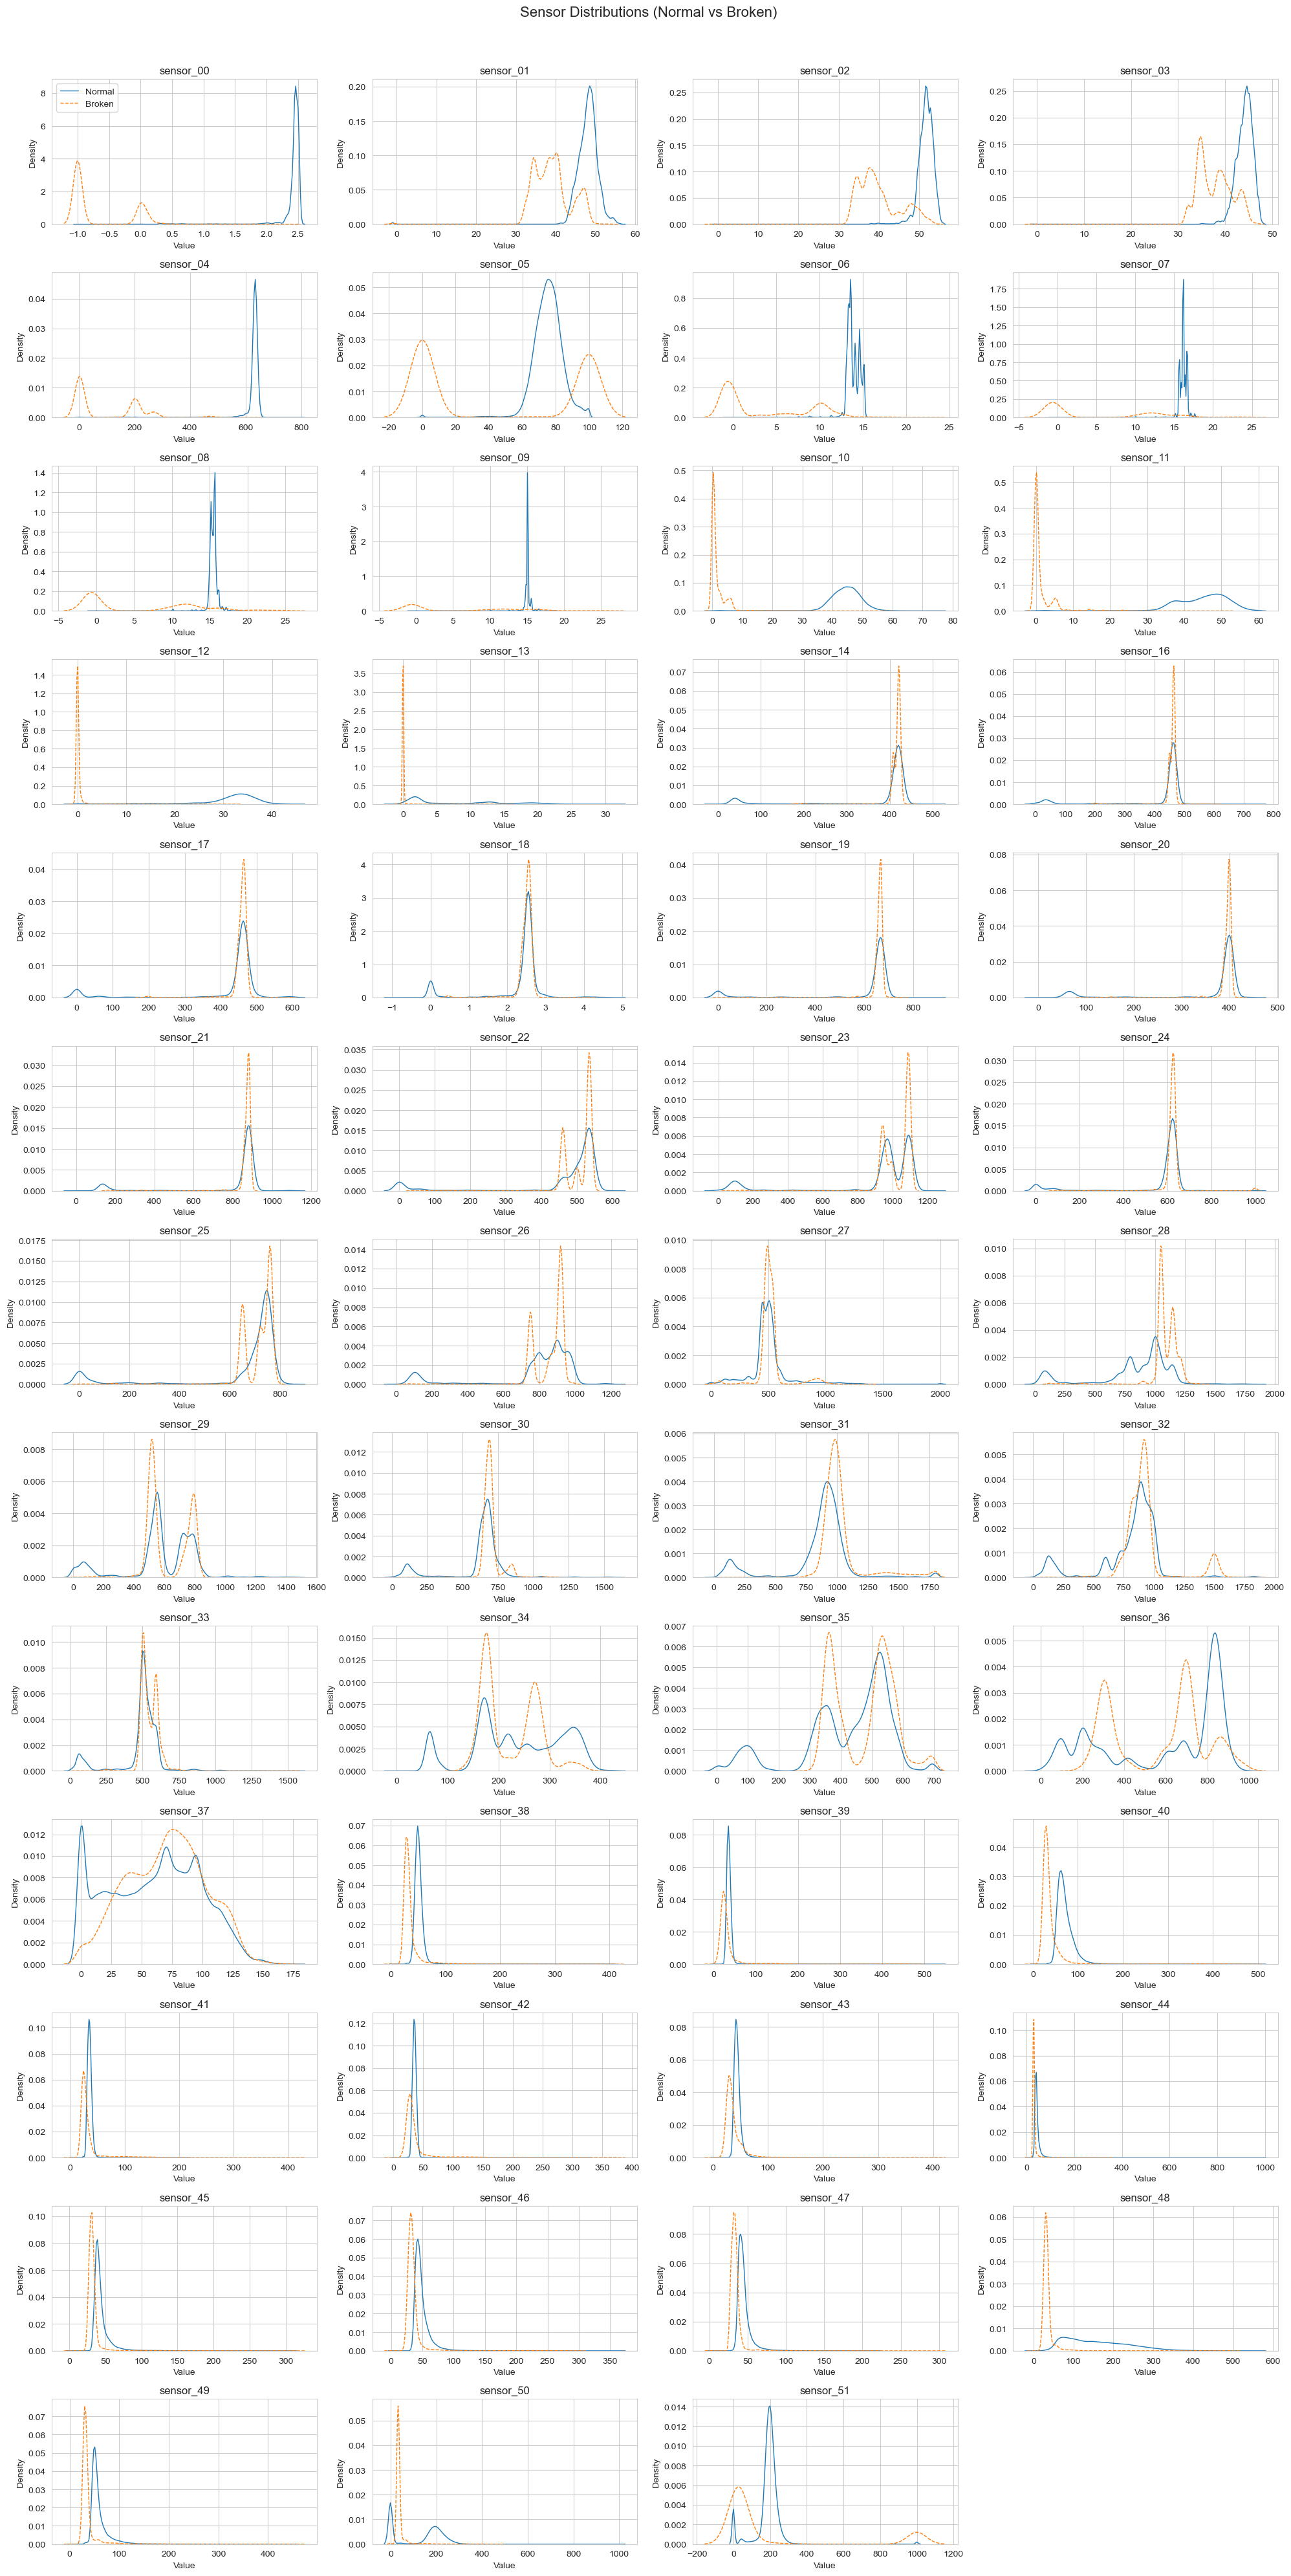

In [26]:
plot_all_sensor_distributions(df)

In [29]:
final_sensors = ['sensor_00', 'sensor_04', 'sensor_06', 'sensor_07',
                 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11',
                 'sensor_12']

The code performs data exploration and preprocessing on a sensor dataset.

**Data Exploration:**

1.  **Initial Inspection:** The code starts by loading the dataset and displaying the first few rows, along with general information about the data types and non-null values.  It also checks for missing values in each column.

2.  **Class Distribution:** The `plot_class_distribution` function visualizes the distribution of the 'machine/_status' column (and later, a re-labeled 'labels' column). This helps understand the balance of different machine states (e.g., NORMAL, BROKEN).

3.  **Time Series Analysis:** The code converts the 'timestamp' column to datetime objects and plots the 'machine/_status' over time. This is crucial for identifying any temporal patterns or trends in the data.  It then relabels the machine status for improved visualization, with BROKEN encompassing all non-NORMAL statuses.  

4. **Missing Value Analysis:** The code calculates and visualizes the percentage of missing values for each sensor column. A bar plot highlights sensors with the highest missing value proportions.


**Data Preprocessing:**

1.  **Label Encoding:** The `LabelEncoder` is used to convert the categorical 'machine/_status' into numerical labels for machine learning models. A time-shifted label is then introduced to account for a 10 minute delay.

2.  **Feature Selection and Missing Value Imputation:** The code drops irrelevant columns (e.g., 'machine/_status', 'sensor/_15') and fills missing values in the sensor columns with -1. The sensors with a high number of missing values are dropped.

3.  **Time Shift:**  A critical preprocessing step involves shifting the labels by 10 minutes. This simulates a real-world scenario where the current sensor readings might predict the machine status 10 minutes into the future. The last 10 rows are dropped because of the shift.

4.  **Sensor Distribution Visualization:**  The code plots the distribution of each sensor's values for normal and broken machine states using kernel density estimation (KDE).  This visualization helps identify sensors that might be highly discriminative between the two states.

5. **Feature Selection**: Several features are selected from the sensors which appear to provide good separation in the distributions of broken and normal states. These sensors are further analysed in later steps.



**Findings (implied by the code):**

*   The dataset contains missing values, primarily in certain sensor readings.  A threshold of missing data was used to remove one feature.
*   The class distribution of the machine status shows the proportion of normal and abnormal states.
*   There appears to be a time dependency in the machine status, which is addressed through time-shifted labeling.
*   Certain sensors exhibit different value distributions between normal and broken states, suggesting these sensors are good indicators for predicting machine failures.
*   Some sensor readings are more useful than others for classifying machine status.


2. Feature Engineering

In [32]:
def get_new_features(sensor_list, df):
    """
    Function to find distance from normal state mean value
    """
    new_features = {}
    for sensor in sensor_list:
        val = df[sensor] - np.mean(df[df['labels']==0][sensor].values)
        new_features[sensor] = val
    new_features['labels'] = df['labels']
    new_df = pd.DataFrame(new_features)
    return new_df

In [33]:
import numpy as np

# dist from mean of normal state
df_dist_from_norm_mean = get_new_features(final_sensors, data_10min_shift)
df_dist_from_norm_mean.head()

,sensor_00,sensor_04,sensor_06,sensor_07,sensor_08,sensor_09,sensor_10,sensor_11,sensor_12,labels
0,0.045599,8.811367,-0.452019,-0.033137,0.090218,-0.03195,-7.029786,2.768899,-0.045803,0.0
1,0.045599,8.811367,-0.452019,-0.033137,0.090218,-0.03195,-7.029786,2.768899,-0.045803,0.0
2,0.024939,13.325267,-0.538829,-0.127167,0.140858,-0.07535,-6.389416,3.421909,0.925977,0.0
3,0.040679,2.561367,-0.546059,0.082613,0.220428,-0.00301,-5.677416,3.900749,0.509247,0.0
4,0.025923,10.894667,-0.509889,0.046443,0.220428,-0.00301,-4.767796,4.307659,0.789057,0.0


In [34]:
from sklearn.model_selection import train_test_split

# Assuming 'df_dist_from_norm_mean' is your feature engineered DataFrame
X = df_dist_from_norm_mean.drop('labels', axis=1)  # Features
y = df_dist_from_norm_mean['labels']  # Target variable

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [35]:
def percentage_cls_distrib(df):
    """
    function to get % class distribution among train and test data
    """
    total = len(df)
    class_0 = round(df.value_counts()[0] *100 / total, 2)
    class_1 = round(df.value_counts()[1] *100 / total, 2)
    print(f"% Normal class data points = {class_0}")
    print(f"% Broken class data points= {class_1}")

In [36]:
def percentage_cls_distrib(df):
    """
    function to get % class distribution among train and test data
    """
    total = len(df)
    class_0 = round(df.value_counts()[0] * 100 / total, 2)
    class_1 = round(df.value_counts()[1] * 100 / total, 2)
    print(f"% Normal class data points = {class_0}")
    print(f"% Broken class data points= {class_1}")

print("Training data class distribution:")
percentage_cls_distrib(y_train)

print("/nTest data class distribution:")
percentage_cls_distrib(y_test)

Training data class distribution:
% Normal class data points = 93.4
% Broken class data points= 6.6
/nTest data class distribution:
% Normal class data points = 93.53
% Broken class data points= 6.47


In [56]:
def normalize_df(df_train, df_test):
    """
    Function to normalize the data using minimax scaler
    """
    scaler = MinMaxScaler()
    scaled_train = scaler.fit_transform(df_train.values)
    scaled_test = scaler.transform(df_test.values)
    train = pd.DataFrame(data=scaled_train,
                         columns=df_train.columns,
                         index=df_train.index)
    test = pd.DataFrame(data=scaled_test,
                        columns=df_test.columns,
                        index=df_test.index)
    return train, test, scaler

In [58]:
X_train, X_test, scaler = normalize_df(X_train, X_test)

**Feature Engineering Summary and Findings:**

The code performs a crucial feature engineering step by calculating the distance of each sensor's value from the mean of that sensor's values during normal operation. This creates new features representing deviations from the typical normal state.

**List of Features with Justifications:**

The original sensor readings (`sensor_00`, `sensor_04`, `sensor_06`, `sensor_07`, `sensor_08`, `sensor_09`, `sensor_10`, `sensor_11`, `sensor_12`) were pre-selected based on their ability to distinguish between normal and broken machine states as observed in their distributions.

The feature engineering step generates new features based on these pre-selected sensors:

*   **`sensor_XX` (where XX is 00, 04, 06, 07, 08, 09, 10, 11, 12):**  The distance of each sensor reading from the mean value of that sensor during normal operation.  This is justified by the hypothesis that deviations from normal operating parameters are indicative of potential machine failure.  Large positive deviations might signify abnormal behavior.


**Findings:**

The newly engineered features are intended to improve the performance of machine learning models by highlighting deviations from the expected normal behavior, potentially making it easier for models to identify anomalies that signal impending machine failure.  The code proceeds to split the data and normalize the values. The class distribution after splitting the data into train and test remains unbalanced.


3. Model Development

In [62]:
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append([name, accuracy, precision, recall, f1])

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
print(results_df)

# Find the best model based on a chosen metric (e.g., accuracy)
best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
print(f"/nBest model based on accuracy: {best_model_name}")

                    Model  Accuracy  Precision    Recall  F1-Score
0     Logistic Regression  0.996936   0.965057  0.988421  0.976599
1  Support Vector Machine  0.999115   0.995069  0.991228  0.993145
2           Decision Tree  0.999614   0.995800  0.998246  0.997021
3     K-Nearest Neighbors  0.999455   0.995789  0.995789  0.995789
4             Naive Bayes  0.986224   0.826873  0.995439  0.903359
5           Random Forest  0.999705   0.997545  0.997895  0.997720
/nBest model based on accuracy: Random Forest


# Model Development Summary and Discussion of Best Model

## Model Training and Evaluation
The code trains six different machine learning models (Logistic Regression, SVM, Decision Tree, KNN, Naive Bayes, and Random Forest) on the preprocessed sensor data.  The models are evaluated using standard classification metrics: accuracy, precision, recall, and F1-score.

## Discussion of Results
The provided code evaluates the performance of multiple machine learning models using common metrics like Accuracy, Precision, Recall, and F1-Score.  It then identifies the best model based on accuracy, demonstrating a basic model selection process.  However, a deeper analysis is needed to fully understand model performance and generalization capabilities:

1. Detailed performance analysis for each model: Instead of just reporting the best model based on accuracy, the analysis should delve into the performance of each model. Consider:
    - Confusion matrices: Visualizing true positives, true negatives, false positives, and false negatives for a nuanced view of the classifier's performance.
    - ROC curves and AUC scores:  Assessing the model's ability to distinguish between classes across various thresholds, especially important for imbalanced datasets.
    - Precision-recall curves: Useful when dealing with class imbalances, showcasing the trade-off between precision and recall.

2. Addressing Class Imbalance: The dataset exhibits an imbalance between normal and abnormal states.  Addressing the imbalance is crucial, as accuracy can be misleading in such cases.  Techniques to consider include:
    - Resampling (oversampling the minority class or undersampling the majority class)
    - Cost-sensitive learning (assigning different misclassification costs to different classes)
    - Using evaluation metrics more sensitive to class imbalances (e.g., F1-score)

3. Cross-validation: Instead of a single train-test split, employ k-fold cross-validation to obtain more robust performance estimates.  This technique will provide a more reliable measure of model generalization.

4. Hyperparameter Tuning: The performance of each model might be improved by optimizing its hyperparameters. Grid search or randomized search can be used to find the optimal settings.

5. Feature Importance Analysis: Analyze which features the best model finds most important. This provides insight into the underlying factors that lead to machine failure and can be used to further improve the model or understand the system better.

6.  Model Explainability: Consider methods to explain the model’s predictions (e.g., SHAP values or LIME).


## Conclusion
While the code provides a basic model selection process, a more rigorous evaluation and analysis are necessary to select the best model for this classification problem.  Addressing the class imbalance, performing cross-validation, hyperparameter tuning, and using a broader set of evaluation metrics will result in a better model that generalizes well to unseen data.  Further, feature importance analysis and model explainability can add a wealth of information.

In [66]:
import joblib

# Assuming 'best_model_name' holds the name of the best model
best_model = models[best_model_name]

# Save the best model
joblib.dump(best_model, 'C:/Users/HP/Downloads/AI Engineer Assignment/AI Engineer Assignment/best_model.pkl')

# Save the scaler
joblib.dump(scaler, 'C:/Users/HP/Downloads/AI Engineer Assignment/AI Engineer Assignment/scaler.pkl')

['C:/Users/HP/Downloads/AI Engineer Assignment/AI Engineer Assignment/scaler.pkl']

In [70]:
import pandas as pd
import joblib
import numpy as np

# Load the trained model and scaler
best_model = joblib.load('C:/Users/HP/Downloads/AI Engineer Assignment/AI Engineer Assignment/best_model.pkl')
scaler = joblib.load('C:/Users/HP/Downloads/AI Engineer Assignment/AI Engineer Assignment/scaler.pkl')

final_sensors = ['sensor_00', 'sensor_04', 'sensor_06', 'sensor_07',
                 'sensor_08', 'sensor_09', 'sensor_10', 'sensor_11',
                 'sensor_12']

def get_new_features(sensor_list, df):
    new_features = {}
    for sensor in sensor_list:
        val = df[sensor] - np.mean(df[sensor])  # Use mean from input
        new_features[sensor] = val
    return pd.DataFrame(new_features)

def predict_machine_status(user_input):
    user_df = pd.DataFrame([user_input])
    missing_cols = set(final_sensors) - set(user_df.columns)
    for col in missing_cols:
        user_df[col] = 0
    user_df = user_df[final_sensors]
    user_df = get_new_features(final_sensors, user_df)
    user_df_scaled = pd.DataFrame(scaler.fit_transform(user_df), columns=user_df.columns)
    prediction = best_model.predict(user_df_scaled)[0]
    return 'NORMAL' if prediction == 0 else 'BROKEN'

# 🧠 Accept input from the user
print("Enter sensor readings:")
user_input = {}
for sensor in final_sensors:
    val = input(f"Enter value for {sensor}: ")
    try:
        user_input[sensor] = float(val)
    except ValueError:
        user_input[sensor] = 0.0  # Default value if input is invalid

# Run prediction
result = predict_machine_status(user_input)
print(f"\nPredicted Machine Status: {result}")

Enter sensor readings:


Enter value for sensor_00:  0
Enter value for sensor_04:  202.526
Enter value for sensor_06:  3.219039
Enter value for sensor_07:  16.89091
Enter value for sensor_08:  16.86921
Enter value for sensor_09:  15.08247
Enter value for sensor_10:  35.53085
Enter value for sensor_11:  3.625588
Enter value for sensor_12:  1.602259



Predicted Machine Status: NORMAL
